# Word Embeddings: A Hands-On Toolbox

In this lab you will build a practical toolkit for turning **words** (and, it turns out, almost anything that comes in sequences) into **vectors** you can compute with. It is the applied companion to today's slides: the distributional hypothesis, Word2Vec, cosine similarity, tf-idf, and topic models all show up here as runnable code.

By the end of this lab you will be able to:

1. **Load and use pretrained word embeddings** — vectors trained for you on billions of words
2. **Measure similarity and solve analogies** — cosine similarity and vector arithmetic
3. **Visualize an embedding space** in 2D with PCA and t-SNE
4. **Train your own embeddings** with Word2Vec — on words, or on *any* sequence (the X2Vec trick)
5. **Represent documents** with tf-idf and with averaged embeddings, and train a classifier
6. **Gather your own text data** from Project Gutenberg, a lyrics API, or the open web

Think of this notebook as a **reference you can raid** for your project. Every section is a small, self-contained tool — copy the pieces you need and remix them.

---

In [1]:
! pip install --upgrade --force-reinstall --no-cache-dir gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.4/24.4 MB 2.8 MB/s  0:00:08a 0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 2.7 MB/s  0:00:01a 0:00:01m eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.4/20.4 MB 3.0 MB/s  0:00:06a 0:00:010:00:01:01
  Attempting uninstall: wrapt
    Found existing installation: wrapt 1.17.0
    Uninstalling wrapt-1.17.0:
      Successfully uninstalled wrapt-1.17.0
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.5
    Uninstalling numpy-2.3.5:
      Successfully uninstalled numpy-2.3.5
  Attempting uninstall: scipy╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [numpy]
    Found existing installation: scipy 1.16.3━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1/5 [numpy]
    Uninstalling scipy-1.16.3:━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━ 3/5 [scipy]
      Successfully uninstalled scipy-1.16.30m╺━━━━━━━━━━━━━━━ 3/5 [scipy]
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [gensim]━━━━ 4/5 [gensim]
ERROR: pip's dependency resolv

## Section 0: Setup & Imports

This lab leans on three workhorses:

| Library | What we use it for |
|---|---|
| `gensim` | loading pretrained embeddings, training Word2Vec |
| `scikit-learn` | tf-idf, PCA / t-SNE, a simple classifier |
| `requests` / `beautifulsoup4` | fetching and parsing your own text |

If any are missing, install them once:
```
pip install gensim scikit-learn requests beautifulsoup4 matplotlib
```

A few cells in this notebook reach out to the internet to download data. **Each of those is wrapped in a `try`/`except`**, so the notebook keeps running even if you are offline — the offline examples (built from synthetic data) always work.

In [2]:
# run once if needed:
# %pip install gensim scikit-learn requests beautifulsoup4 matplotlib

import os
import numpy as np
import matplotlib.pyplot as plt

# a place for generated figures / files
os.makedirs("outputs", exist_ok=True)

# fix the seed so results are reproducible
np.random.seed(0)
print("ready")

ready


---
## Section 1: Pretrained Word Embeddings

Recall the **distributional hypothesis** from the slides: *"you shall know a word by the company it keeps."* A word's meaning is captured by the contexts it appears in, and a good **embedding** turns that idea into a short, dense vector — so that words used in similar ways end up with similar vectors.

Training these vectors from scratch takes a large corpus and some patience. The fastest way to get good ones is to **download vectors someone already trained**. `gensim` ships a downloader for several popular sets; we'll use `glove-wiki-gigaword-100`: GloVe trained on Wikipedia + Gigaword, with **100 numbers per word** (about 128 MB the first time, cached afterward).

In [3]:
import gensim.downloader as api

# downloads ~128 MB the first time, then loads from cache
try:
    wv = api.load("glove-wiki-gigaword-100")
    print("loaded", len(wv.index_to_key), "word vectors, each of dimension", wv.vector_size)
except Exception as e:
    print("could not download embeddings, are you online?", e)
    wv = None

[==================================================] 100.0% 128.1/128.1MB downloaded
loaded 400000 word vectors, each of dimension 100


### 1a. Looking Words Up

Once loaded, `wv` behaves like a dictionary from a word to its vector, and it answers similarity queries directly. Two methods you'll use constantly:

- `wv[word]` — the raw vector (a NumPy array of length 100)
- `wv.similarity(a, b)` — cosine similarity between two words
- `wv.most_similar(word)` — the nearest neighbors in the space

In [4]:
if wv is not None:
    print("vector for 'king' (first 8 of 100 dims):")
    print(np.round(wv["king"][:8], 3))
    print()
    print("similarity(cat, dog):      ", round(wv.similarity("cat", "dog"), 3))
    print("similarity(cat, democracy):", round(wv.similarity("cat", "democracy"), 3))
    print()
    print("nearest neighbors of 'paris':")
    for word, score in wv.most_similar("paris", topn=5):
        print(f"   {word:12s} {score:.3f}")

vector for 'king' (first 8 of 100 dims):
[-0.323 -0.876  0.22   0.253  0.23   0.739 -0.38  -0.353]

similarity(cat, dog):       0.88
similarity(cat, democracy): 0.084

nearest neighbors of 'paris':
   prohertrib   0.799
   france       0.748
   london       0.734
   brussels     0.704
   french       0.693


Notice the pattern: *cat* and *dog* score high (both common pets that appear in similar sentences), while *cat* and *democracy* score low. And the neighbors of *paris* are other cities and France-related words. None of this was hand-coded — it fell out of the contexts these words appeared in.

---
## Section 2: The Embedding Toolkit

You don't actually need a library for the core operations — they are a few lines of NumPy. Understanding them is worth more than memorizing the gensim API.

### Cosine similarity

To compare two vectors we measure the **angle** between them, not the distance. Two vectors pointing the same way are similar regardless of length:

$$\cos(x, y) = \frac{\sum_i x_i y_i}{\sqrt{\sum_i x_i^2}\,\sqrt{\sum_i y_i^2}}$$

A value of **1** means "same direction" (very similar), **0** means unrelated. Euclidean distance measures *magnitude*; cosine measures *orientation*, which is what we want for meaning.

In [11]:
def cosineSim(a, b):
    "cosine similarity between two vectors"
    return float(a @ b / (np.linalg.norm(a) * np.linalg.norm(b)))

def nearestNeighbors(vec, vectors, words, topn=5):
    "return the topn words whose vectors are closest to vec by cosine"
    scored = [(w, cosineSim(vec, vectors[i])) for i, w in enumerate(words)]
    scored.sort(key=lambda p: p[1], reverse=True)
    return scored[:topn]

if wv is not None:
    print("by hand, cosine(king, queen):", round(cosineSim(wv["king"], wv["queen"]), 3))
    print("by hand, cosine(window, queen):", round(cosineSim(wv["window"], wv["queen"]), 3))
    print("gensim agrees, similarity:   ", round(wv.similarity("king", "queen"), 3))

by hand, cosine(king, queen): 0.751
by hand, cosine(window, queen): 0.289
gensim agrees, similarity:    0.751


Our hand-written `cosineSim` matches gensim's `similarity` exactly — there is no magic, just a dot product over two norms.

### 2a. Analogies: Meaning as Direction

The famous party trick of word embeddings is that **relationships become directions**. The vector from *man* to *woman* is roughly the same as the vector from *king* to *queen*, so:

$$v(\text{king}) - v(\text{man}) + v(\text{woman}) \approx v(\text{queen})$$

We can solve `a : b :: c : ?` by computing `v(b) - v(a) + v(c)` and finding its nearest neighbor.

In [12]:
if wv is not None:
    print("king - man + woman ~", wv.most_similar(positive=["king", "woman"], negative=["man"], topn=3))
    print("paris - france + italy ~", wv.most_similar(positive=["paris", "italy"], negative=["france"], topn=3))
    print("walking - walked + swam ~", wv.most_similar(positive=["walking", "swam"], negative=["walked"], topn=3))

king - man + woman ~ [('queen', 0.7698541283607483), ('monarch', 0.6843381524085999), ('throne', 0.6755736470222473)]
paris - france + italy ~ [('rome', 0.8189547061920166), ('milan', 0.7376196980476379), ('naples', 0.7117616534233093)]
walking - walked + swam ~ [('swimming', 0.706767201423645), ('swim', 0.7048406004905701), ('biking', 0.6536762118339539)]


The first returns *queen*, the second *rome*, the third *swimming* — gender, capital-of, and verb-tense each show up as a consistent direction.

A word of caution worth carrying into your project: analogies are **cherry-picked**. They work beautifully on textbook examples and fail on plenty of others. Probing *where* they break is itself an interesting thing to investigate.

---
## Section 3: Visualizing the Space

Word vectors live in 100s of dimensions, which we cannot see. To look at them we **project** down to 2D. Two common tools, both in scikit-learn:

| Method | Idea | Trade-off |
|---|---|---|
| **PCA** | keep the directions of greatest variance | fast, linear, preserves global structure |
| **t-SNE** | preserve local neighborhoods | slower, non-linear, great for showing clusters |

Let's write one helper and reuse it.

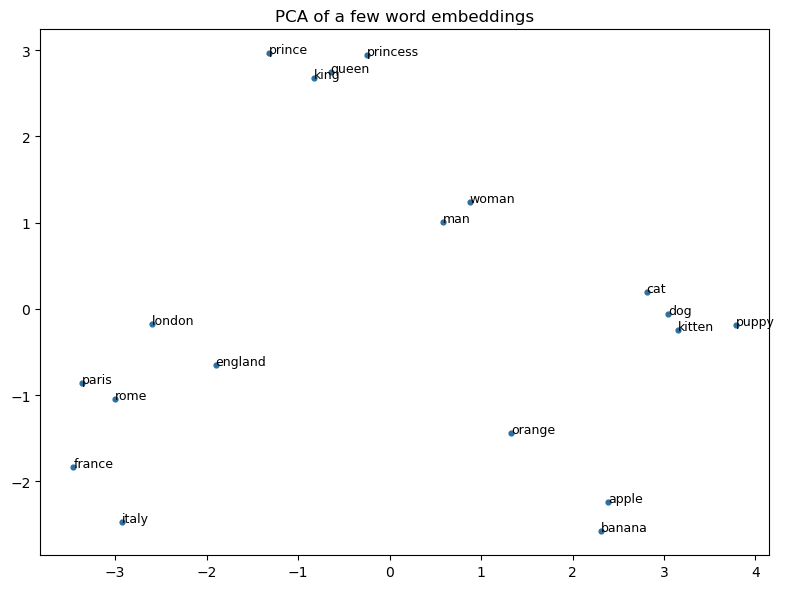

In [13]:
from sklearn.decomposition import PCA

def plotWords(words, vectors, title="word embeddings"):
    "project vectors to 2d with pca and scatter them with labels"
    coords = PCA(n_components=2).fit_transform(np.array(vectors))
    plt.figure(figsize=(8, 6))
    plt.scatter(coords[:, 0], coords[:, 1], s=12, color="#2f6f9f")
    for (x, y), w in zip(coords, words):
        plt.annotate(w, (x, y), fontsize=9)
    plt.title(title)
    plt.tight_layout()
    plt.show()
    return coords

if wv is not None:
    sample = ["king", "queen", "prince", "princess", "man", "woman",
              "paris", "london", "rome", "france", "england", "italy",
              "dog", "cat", "puppy", "kitten", "apple", "banana", "orange"]
    _ = plotWords(sample, [wv[w] for w in sample], title="PCA of a few word embeddings")

Even in a flat 2D shadow of the full space, the families separate: royalty in one area, cities and countries in another, animals and fruit elsewhere. The geometry encodes meaning.

### 3a. t-SNE for Tighter Clusters

t-SNE often shows cleaner clusters because it cares about preserving *local* neighborhoods rather than global variance. It is slower, so we keep the word list small.

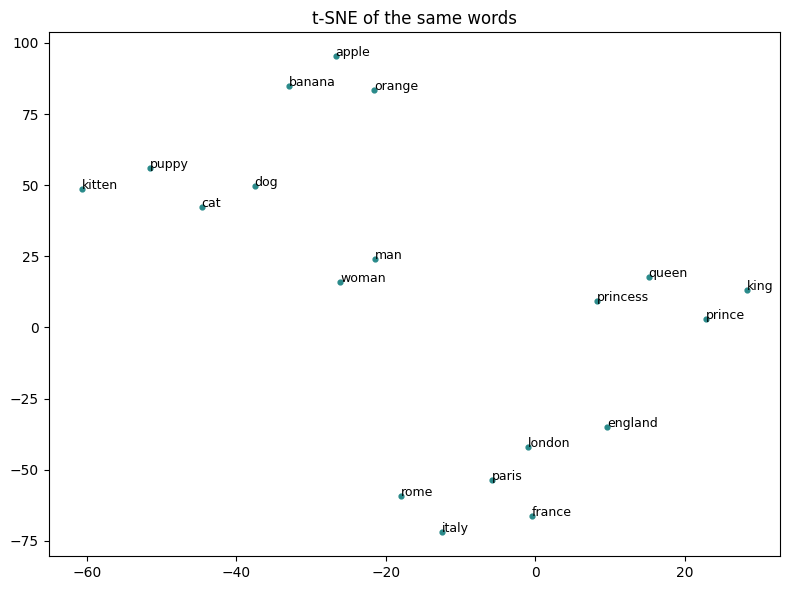

In [8]:
from sklearn.manifold import TSNE

if wv is not None:
    words = sample
    X = np.array([wv[w] for w in words])
    # perplexity must be < number of points
    coords = TSNE(n_components=2, perplexity=5, init="pca", random_state=0).fit_transform(X)
    plt.figure(figsize=(8, 6))
    plt.scatter(coords[:, 0], coords[:, 1], s=12, color="#2a8a8a")
    for (x, y), w in zip(coords, words):
        plt.annotate(w, (x, y), fontsize=9)
    plt.title("t-SNE of the same words")
    plt.tight_layout()
    plt.show()

---
## Section 4: Train Your Own Embeddings

Downloaded vectors are convenient, but you can **train your own** with `gensim.models.Word2Vec`. The input is simply a list of sequences of tokens. Word2Vec slides a window over each sequence and learns vectors that are good at predicting which words appear near which — exactly the skip-gram setup from the slides.

In [14]:
from gensim.models import Word2Vec

mini_corpus = [
    "the cat sat on the mat".split(),
    "the dog sat on the rug".split(),
    "a cat chased a mouse".split(),
    "a dog chased a cat".split(),
    "the kitten drank the milk".split(),
]

# sg=1 selects skip-gram; vector_size is the embedding dimension
toy = Word2Vec(sentences=mini_corpus, vector_size=16, window=2,
               min_count=1, sg=1, epochs=50, workers=1)

print("nearest to 'cat' in our tiny model:", [w for w, _ in toy.wv.most_similar("cat", topn=3)])

nearest to 'cat' in our tiny model: ['mat', 'a', 'kitten']


Five sentences is far too little data for good vectors, but even here *cat* lands near *kitten*. With a real corpus (a book, a pile of reviews, a subreddit) the vectors get genuinely useful.

### 4a. The X2Vec Trick: Embed Anything

Here is the idea worth stealing for your project: **Word2Vec does not care that the tokens are words.** Any list of sequences works. If songs that appear together in playlists are "context" for each other, you get **Song2Vec**. If courses a student takes are context, you get course2vec.

Below is a fully self-contained **Song2Vec** on synthetic playlists, so you can watch the idea work before plugging in real data.

In [17]:
import random
random.seed(0)

# four genres, eight songs each; playlists are mostly within one genre
genres = {g: [f"{g}_{i}" for i in range(8)] for g in ["pop", "rock", "jazz", "classical"]}

def makePlaylist():
    "a playlist that is mostly one genre, with the occasional crossover track"
    g = random.choice(list(genres))
    playlist = [random.choice(genres[g]) for _ in range(random.randint(8, 15))]
    if random.random() < 0.2:
        other = random.choice(list(genres))
        playlist += [random.choice(genres[other]) for _ in range(2)]
    random.shuffle(playlist)
    return playlist

playlists = [makePlaylist() for _ in range(2000)]

# treat each playlist exactly like a "sentence" of song tokens
song2vec = Word2Vec(sentences=playlists, vector_size=32, window=5,
                    min_count=1, sg=1, epochs=30, workers=1)

print("nearest to pop_0: ", [w for w, _ in song2vec.wv.most_similar("pop_0", topn=4)])
print("nearest to jazz_3:", [w for w, _ in song2vec.wv.most_similar("jazz_3", topn=4)])

nearest to pop_0:  ['pop_4', 'pop_6', 'pop_1', 'pop_5']
nearest to jazz_3: ['jazz_4', 'jazz_2', 'jazz_5', 'jazz_0']


The nearest neighbors of `pop_0` are other pop songs, and the neighbors of `jazz_3` are other jazz songs — **the model recovered genre from playlist co-occurrence alone**, with no genre labels ever given to it. Let's see the clusters.

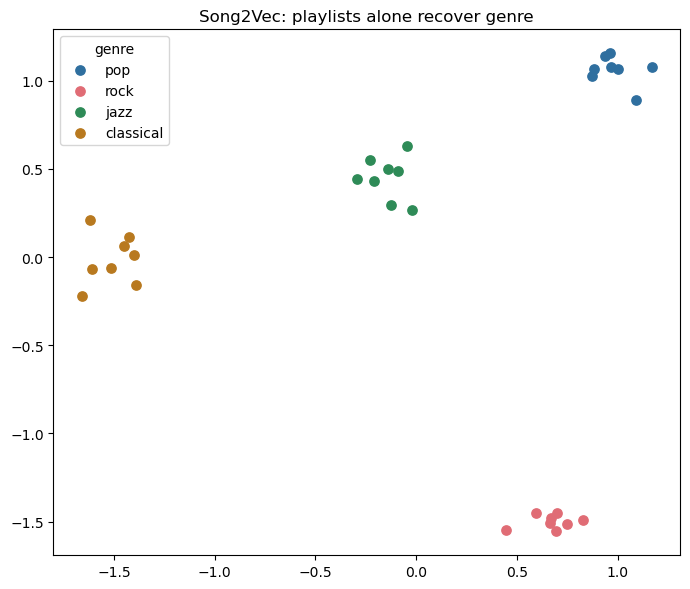

In [18]:
all_songs = list(song2vec.wv.index_to_key)
genre_of = {s: s.split("_")[0] for s in all_songs}
palette = {"pop": "#2f6f9f", "rock": "#e06c75", "jazz": "#2e8b57", "classical": "#b8791f"}

coords = PCA(n_components=2).fit_transform(np.array([song2vec.wv[s] for s in all_songs]))

plt.figure(figsize=(7, 6))
# one scatter call per genre, so each genre gets a single legend entry
for genre, color in palette.items():
    idx = [i for i, s in enumerate(all_songs) if genre_of[s] == genre]
    plt.scatter(coords[idx, 0], coords[idx, 1], color=color, s=45, label=genre)
plt.title("Song2Vec: playlists alone recover genre")
plt.legend(title="genre")
plt.tight_layout()
plt.show()

Four clean clusters, one per genre. This is the whole project in miniature: pick sequences from a domain you care about, embed them, and the structure reveals itself.

---
## Section 5: Text as Features

Before embeddings, the workhorse way to feed text to a classifier was **tf-idf**: weight each word by how often it appears in a document, scaled down by how common it is across the whole collection.

$$\text{tfidf}(t, d) = \text{tf}_{t,d} \times \log \frac{N}{D_t}$$

Here $\text{tf}_{t,d}$ is the count of term $t$ in document $d$, $N$ is the number of documents, and $D_t$ is how many documents contain $t$. Ubiquitous words like *the* get an IDF near zero; distinctive words score high. It is still a **strong, fast baseline**.

In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

# try a real dataset; fall back to a tiny inline one if offline
try:
    from sklearn.datasets import fetch_20newsgroups
    cats = ["rec.sport.hockey", "sci.space"]
    raw = fetch_20newsgroups(subset="train", categories=cats,
                             remove=("headers", "footers", "quotes"))
    texts, labels = raw.data, list(raw.target)
    print("loaded 20newsgroups:", len(texts), "documents across", cats)
except Exception as e:
    print("offline fallback corpus:", e)
    texts = ["the team scored a goal in overtime", "the goalie made a great save",
             "the rocket reached orbit around mars", "the telescope imaged a galaxy",
             "hockey playoffs start tonight", "the spacecraft landed on the moon"]
    labels = [0, 0, 1, 1, 0, 1]

loaded 20newsgroups: 1193 documents across ['rec.sport.hockey', 'sci.space']


In [13]:
x_train, x_test, y_train, y_test = train_test_split(
    texts, labels, test_size=0.3, random_state=0)

vectorizer = TfidfVectorizer(stop_words="english", min_df=1)
x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

clf = LogisticRegression(max_iter=1000).fit(x_train_tfidf, y_train)
preds = clf.predict(x_test_tfidf)
print("tf-idf + logistic regression")
print("  accuracy:", round(accuracy_score(y_test, preds), 3))
print("  macro f1:", round(f1_score(y_test, preds, average="macro"), 3))

tf-idf + logistic regression
  accuracy: 0.953
  macro f1: 0.953


### 5a. Averaged-Embedding Features

A different way to turn a document into a fixed-length vector: **average the embeddings of its words**. This throws away word order (just like bag-of-words) but keeps the rich meaning baked into the embeddings.

In [14]:
def documentVector(text, wv):
    "represent a document as the average of its word embeddings"
    tokens = [t for t in text.lower().split() if t in wv]
    if not tokens:
        
        return np.zeros(wv.vector_size)
    return np.mean([wv[t] for t in tokens], axis=0)

if wv is not None:
    x_train_emb = np.array([documentVector(t, wv) for t in x_train])
    x_test_emb = np.array([documentVector(t, wv) for t in x_test])
    clf_emb = LogisticRegression(max_iter=1000).fit(x_train_emb, y_train)
    preds_emb = clf_emb.predict(x_test_emb)
    print("averaged-embedding + logistic regression")
    print("  accuracy:", round(accuracy_score(y_test, preds_emb), 3))
    print("  macro f1:", round(f1_score(y_test, preds_emb, average="macro"), 3))
else:
    print("embeddings not loaded; skipping the averaged-embedding classifier")

averaged-embedding + logistic regression
  accuracy: 0.922
  macro f1: 0.922


Compare the two scores. On clean, topic-separated text, tf-idf is often surprisingly hard to beat; on messier or smaller data, averaged embeddings can pull ahead because they share information between related words. **Trying both and reporting which wins is a great project on its own.**

---
## Section 6: Getting Your Own Text Data

The most interesting projects use text *you* chose. Here are runnable starting points for a few sources (the project brief PDF lists many more). All are guarded so they fail gracefully offline.

> **Be a good citizen.** Skim a source's terms of use before scraping or redistributing, prefer public-domain or openly-licensed text, and do not hammer servers.

### 6a. Project Gutenberg (public-domain books)

The Gutendex API lets you search Project Gutenberg and grab a book's plain text.

In [21]:
import requests

def fetchGutenbergText(query):
    "search gutendex and return (title, plain_text) of the first matching book"
    meta = requests.get("https://gutendex.com/books",
                        params={"search": query}, timeout=30).json()
    book = meta["results"][0]
    text_url = next(u for fmt, u in book["formats"].items() if fmt.startswith("text/plain"))
    return book["title"], requests.get(text_url, timeout=30).text

try:
    title, body = fetchGutenbergText("pride and prejudice austen")
    print("downloaded:", title, "(", len(body), "characters )")
    print(body[1000:1250])
except Exception as e:
    print("gutenberg fetch skipped (offline?):", e)

downloaded: Pride and Prejudice ( 763082 characters )

                            [Illustration:

                             GEORGE ALLEN
                               PUBLISHER

                        156 CHARING CROSS ROAD
                                LONDON

                          


### 6b. Song Lyrics

The free `lyrics.ovh` API needs no key and is perfect for a quick demo. (The Genius API is richer but often blocks scripts; for bulk lyrics, the "Genius Song Lyrics" dataset on Kaggle is a reliable alternative.)

In [22]:
def fetchLyrics(artist, title):
    "fetch one song's lyrics from the free lyrics.ovh api"
    r = requests.get(f"https://api.lyrics.ovh/v1/{artist}/{title}", timeout=20)
    return r.json().get("lyrics", "")

try:
    words = fetchLyrics("Queen", "Bohemian Rhapsody")
    print(words[:200] if words else "no lyrics returned")
except Exception as e:
    print("lyrics fetch skipped (offline?):", e)

lyrics fetch skipped (offline?): HTTPSConnectionPool(host='api.lyrics.ovh', port=443): Read timed out. (read timeout=20)


### 6c. Scraping a Web Page

When a site has no API, you can scrape it with `requests` + `BeautifulSoup`. Scrape responsibly: check `robots.txt`, set a `User-Agent`, and pause between requests so you do not overload the server.

In [23]:
from bs4 import BeautifulSoup
import time

def scrapeText(url):
    "fetch a page and return its visible paragraph text (a polite template)"
    headers = {"User-Agent": "ydl-2026-student-project (educational use)"}
    html = requests.get(url, headers=headers, timeout=30).text
    soup = BeautifulSoup(html, "html.parser")
    paragraphs = [p.get_text(" ", strip=True) for p in soup.find_all("p")]
    time.sleep(1)  # be polite between requests
    return "\n".join(paragraphs)

try:
    sample_text = scrapeText("https://en.wikipedia.org/wiki/Natural_language_processing")
    print(sample_text[:300])
except Exception as e:
    print("scrape skipped (offline?):", e)

Natural language processing ( NLP ) is the processing of natural language information by a computer . NLP is a subfield of computer science and is closely associated with artificial intelligence . NLP is also related to information retrieval , knowledge representation , computational linguistics , a


For bigger sources: **Reddit** is available in bulk through the Arctic Shift project (an API and downloadable dumps), and **Hugging Face Datasets** (`pip install datasets`) gives one-line access to thousands of corpora, e.g. `load_dataset("ag_news")`, `load_dataset("imdb")`, or `load_dataset("wikitext", "wikitext-103-raw-v1")`. See the project brief for the full list.